In [15]:
import sys
from pathlib import Path

# trova la root del progetto in modo robusto
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# aggiungi src al PYTHONPATH
src_path = project_root / "src"
sys.path.append(str(src_path))

print("Project root:", project_root)
print("Src path:", src_path)

Project root: /Users/marcotamburi/projects/uni_project/svd_project
Src path: /Users/marcotamburi/projects/uni_project/svd_project/src


In [16]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, Markdown
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from prepare_inputs import prepare_cd_inputs

In [17]:
result = prepare_cd_inputs(
    raw_data_folder=project_root / "data",
    matrix_output_path=project_root / "data" / "matrice_con_t.dat",
    clean_output_path=project_root / "data" / "dati_puliti.csv",
)

matrix_df = result["matrix_df"]
clean_df = result["clean_df"]

display(Markdown("## Anteprima matrice con T"))
display(matrix_df.head())

display(Markdown("## Anteprima dati puliti per SVD"))
display(clean_df.head())

## Anteprima matrice con T

,Wavelength,CD_Tel23_37.5uM_T19,CD_Tel23_37.5uM_T22,CD_Tel23_37.5uM_T24,CD_Tel23_37.5uM_T26,CD_Tel23_37.5uM_T28,CD_Tel23_37.5uM_T30,CD_Tel23_37.5uM_T32,CD_Tel23_37.5uM_T34,CD_Tel23_37.5uM_T36,...,CD_Tel23_37.5uM_T82,CD_Tel23_37.5uM_T84,CD_Tel23_37.5uM_T86,CD_Tel23_37.5uM_T88,CD_Tel23_37.5uM_T90,CD_Tel23_37.5uM_T92,CD_Tel23_37.5uM_T94,CD_Tel23_37.5uM_T96,CD_Tel23_37.5uM_T98,CD_Tel23_37.5uM_T100
0,Wavelength,19.000000,22.000000,24.000000,26.000000,28.000000,30.000000,32.000000,34.000000,36.000000,...,82.000000,84.000000,86.000000,88.000000,90.000000,92.000000,94.000000,96.000000,98.000000,100.000000
1,330.0,0.535653,0.549668,0.547439,0.581914,0.563364,0.612426,0.496127,0.604874,0.598425,...,0.439534,0.435262,0.497140,0.479955,0.403012,0.441934,0.370971,0.431813,0.367093,0.432024
2,329.5,0.521705,0.556836,0.538156,0.581846,0.577134,0.607350,0.504032,0.585079,0.595223,...,0.473242,0.441320,0.474463,0.492177,0.403835,0.436586,0.383931,0.423019,0.348449,0.425564
3,329.0,0.531593,0.573395,0.517939,0.584496,0.570374,0.611856,0.501482,0.571400,0.591140,...,0.463936,0.429568,0.478443,0.473265,0.405304,0.436242,0.364719,0.410306,0.356284,0.414526
4,328.5,0.539488,0.584016,0.546564,0.594529,0.561401,0.623771,0.517139,0.549172,0.574798,...,0.467257,0.436169,0.477730,0.475877,0.389666,0.418678,0.353156,0.410643,0.332987,0.394576


## Anteprima dati puliti per SVD

,1,2,3,4,5,6,7,8,9,10,...,32,33,34,35,36,37,38,39,40,41
0,0.535653,0.549668,0.547439,0.581914,0.563364,0.612426,0.496127,0.604874,0.598425,0.509833,...,0.439534,0.435262,0.497140,0.479955,0.403012,0.441934,0.370971,0.431813,0.367093,0.432024
1,0.521705,0.556836,0.538156,0.581846,0.577134,0.607350,0.504032,0.585079,0.595223,0.509878,...,0.473242,0.441320,0.474463,0.492177,0.403835,0.436586,0.383931,0.423019,0.348449,0.425564
2,0.531593,0.573395,0.517939,0.584496,0.570374,0.611856,0.501482,0.571400,0.591140,0.521280,...,0.463936,0.429568,0.478443,0.473265,0.405304,0.436242,0.364719,0.410306,0.356284,0.414526
3,0.539488,0.584016,0.546564,0.594529,0.561401,0.623771,0.517139,0.549172,0.574798,0.541743,...,0.467257,0.436169,0.477730,0.475877,0.389666,0.418678,0.353156,0.410643,0.332987,0.394576
4,0.528820,0.608973,0.553635,0.608059,0.540713,0.627271,0.533439,0.553204,0.591127,0.535406,...,0.445359,0.445292,0.457624,0.499279,0.375435,0.408440,0.360081,0.405945,0.317857,0.382177


In [18]:
dft_plot = pd.read_csv(project_root / "data" / "matrice_con_t.dat", header=None, sep=",")
dft_plot = dft_plot.replace(",", ".", regex=True)
dft_plot = dft_plot.apply(pd.to_numeric, errors="coerce")

wl = dft_plot.iloc[1:, 0].values
T_celsius = dft_plot.iloc[0, 1:].values.astype(float)

const = (40e-6) * 32980 * 0.1
spectra = dft_plot.iloc[1:, 1:].copy() / const
spectra.columns = T_celsius
spectra.index = wl

print("Wavelengths shape:", wl.shape)
print("Temperature shape:", T_celsius.shape)
print("Spectra shape:", spectra.shape)

Wavelengths shape: (221,)
Temperature shape: (41,)
Spectra shape: (221, 41)


/var/folders/0r/bx5h09pd2p18_5m15hv_vct80000gn/T/ipykernel_2721/2152578592.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


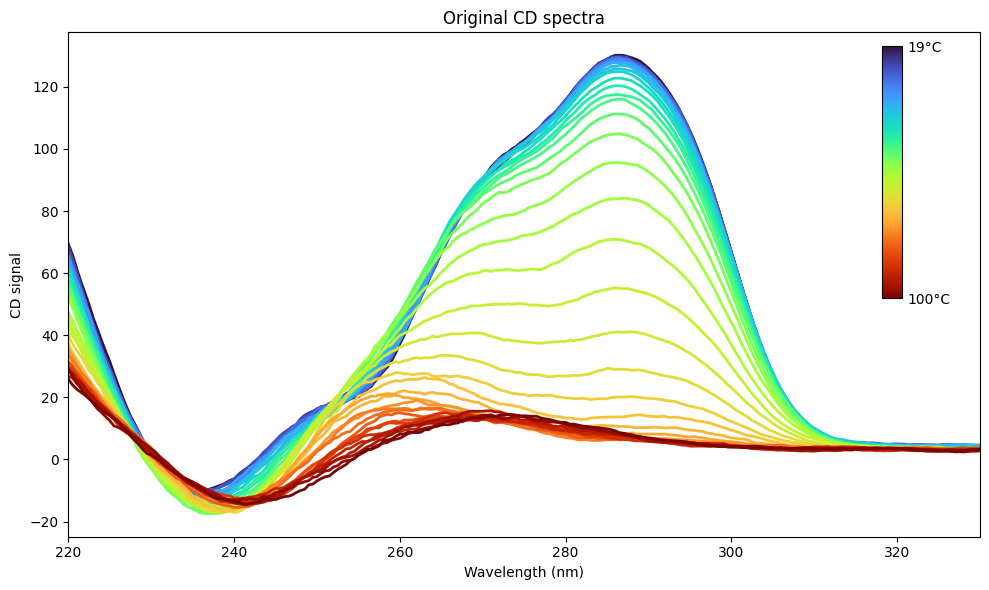

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
spectra.plot(ax=ax, cmap="turbo", linewidth=2, legend=False)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("CD signal")
ax.set_title("Original CD spectra")
ax.set_xlim(wl.min(), wl.max())

sm = plt.cm.ScalarMappable(cmap="turbo")
sm.set_array([])

cax = inset_axes(
    ax,
    width="2.2%",
    height="50%",
    loc="upper right",
    bbox_to_anchor=(-0.07, 0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=1
)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels([f"{T_celsius.min():.0f}°C", f"{T_celsius.max():.0f}°C"])
cbar.ax.tick_params(labelsize=10, length=0)
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
D = clean_df.astype(float).values

U, S, VT = np.linalg.svd(D, full_matrices=False)

print("D shape:", D.shape)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("VT shape:", VT.shape)

D shape: (221, 41)
U shape: (221, 41)
S shape: (41,)
VT shape: (41, 41)


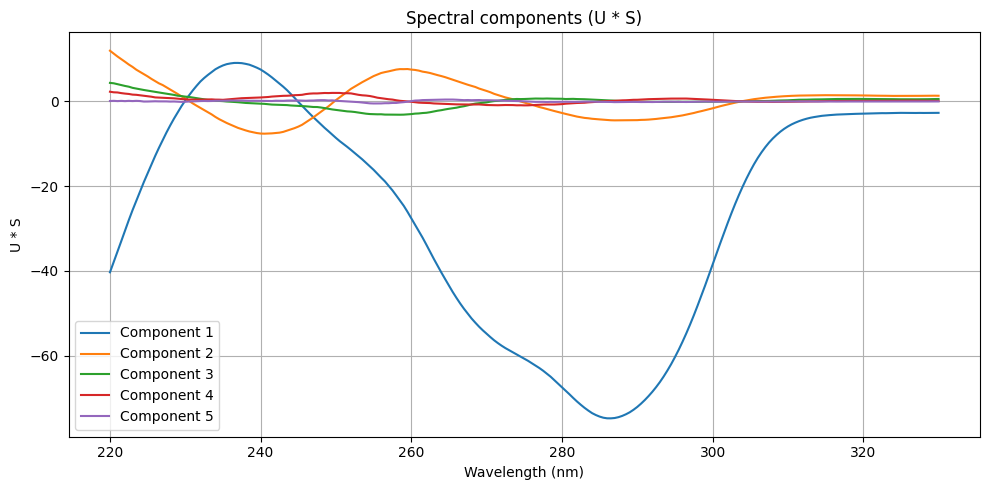

In [21]:
n_plot = min(5, U.shape[1])

plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(wl, U[:, i] * S[i], label=f"Component {i+1}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("U * S")
plt.title("Spectral components (U * S)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

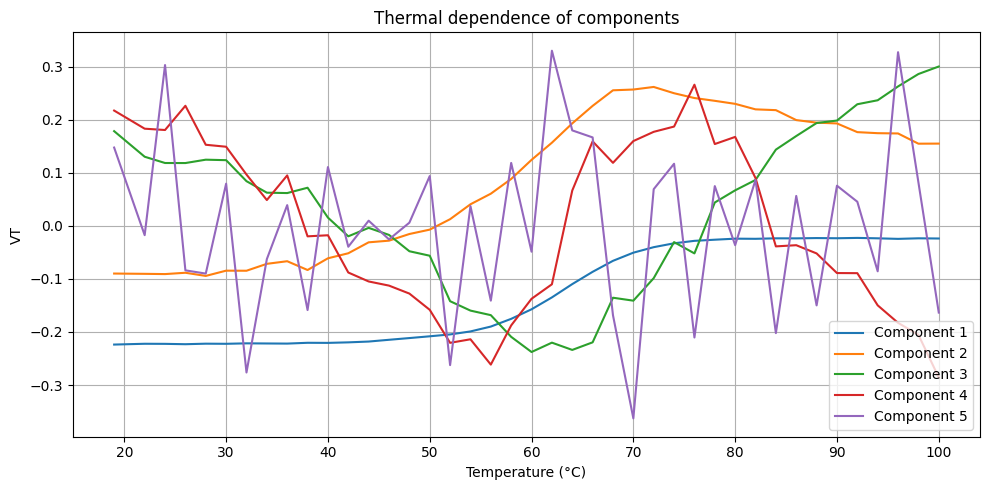

In [22]:
plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(T_celsius, VT[i, :], label=f"Component {i+1}")
plt.xlabel("Temperature (°C)")
plt.ylabel("VT")
plt.title("Thermal dependence of components")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

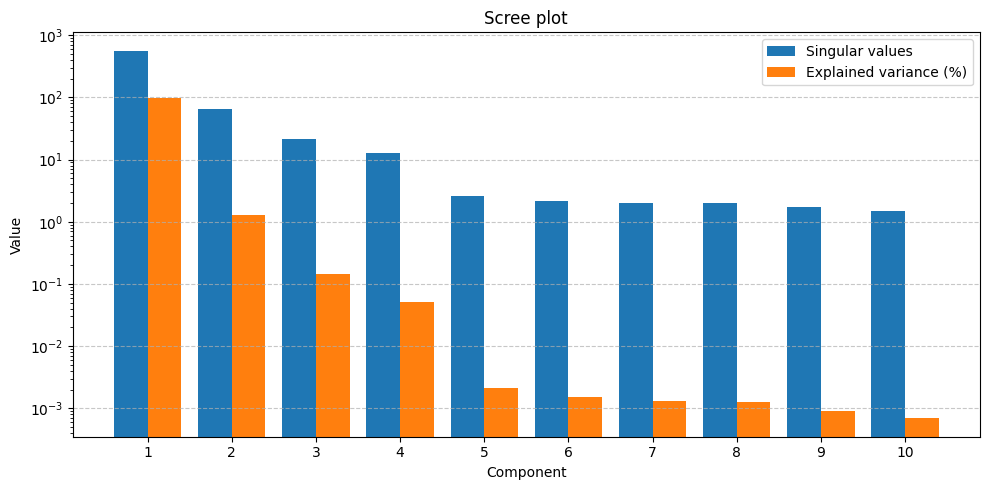

In [23]:
n_samples = D.shape[0]
explained_variance = (S**2) / (n_samples - 1)
explained_variance_ratio = explained_variance / explained_variance.sum() * 100

n_scree = min(10, len(S))
components = np.arange(1, n_scree + 1)

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.4

ax.bar(components - width/2, S[:n_scree], width=width, label="Singular values")
ax.bar(components + width/2, explained_variance_ratio[:n_scree], width=width, label="Explained variance (%)")

ax.set_yscale("log")
ax.set_xlabel("Component")
ax.set_ylabel("Value")
ax.set_title("Scree plot")
ax.set_xticks(components)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

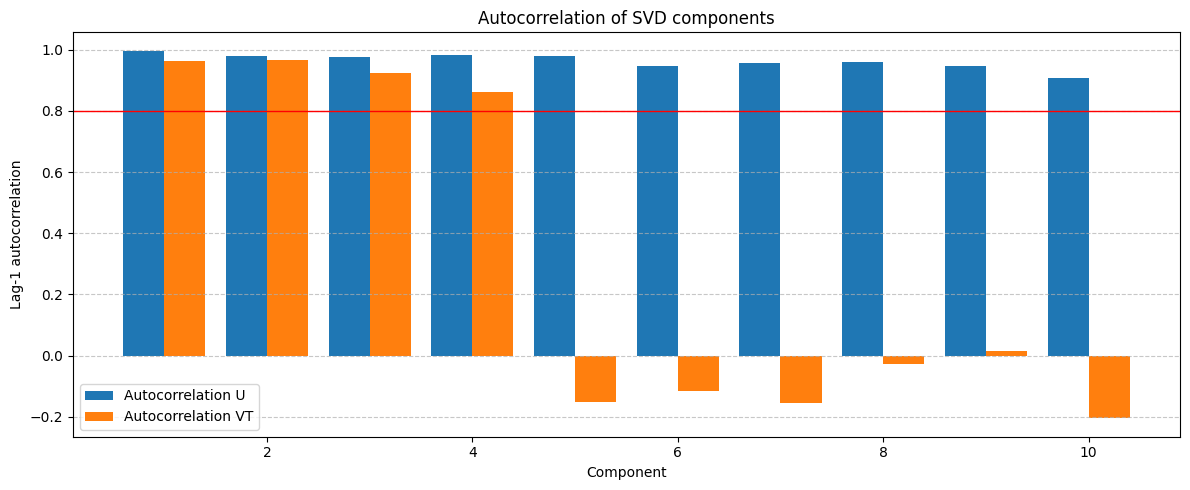

In [24]:
def autocorrelation_lag1_manual(x):
    x = x - np.mean(x)
    num = np.sum(x[:-1] * x[1:])
    den = np.sum(x ** 2)
    return num / den

autocorr_values_U = [autocorrelation_lag1_manual(U[:, i]) for i in range(U.shape[1])]
autocorr_values_VT = [autocorrelation_lag1_manual(VT[i, :]) for i in range(VT.shape[0])]

n_auto = min(10, len(autocorr_values_U))
comp = np.arange(1, n_auto + 1)

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.4

ax.bar(comp - width/2, autocorr_values_U[:n_auto], width=width, label="Autocorrelation U")
ax.bar(comp + width/2, autocorr_values_VT[:n_auto], width=width, label="Autocorrelation VT")

ax.axhline(0.8, color="red", linestyle="-", linewidth=1)
ax.set_xlabel("Component")
ax.set_ylabel("Lag-1 autocorrelation")
ax.set_title("Autocorrelation of SVD components")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
component_selector = widgets.Dropdown(
    options=[2, 3, 4],
    value=4,
    description="n_comp:",
)

display(component_selector)

Dropdown(description='n_comp:', index=2, options=(2, 3, 4), value=4)

In [26]:
k = int(component_selector.value)

U_k = U[:, :k]
S_k = S[:k]
VT_k = VT[:k, :]

U_prime = U_k @ np.diag(S_k)
V_prime = VT_k

u_prime_path = project_root / "data" / "U_prime.csv"
v_prime_path = project_root / "data" / "V_prime.csv"

pd.DataFrame(U_prime).to_csv(u_prime_path, sep="\t", header=False, index=False)
pd.DataFrame(V_prime).to_csv(v_prime_path, sep="\t", header=False, index=False)

print("Saved U_prime to:", u_prime_path)
print("Saved V_prime to:", v_prime_path)
print("U_prime shape:", U_prime.shape)
print("V_prime shape:", V_prime.shape)

Saved U_prime to: /Users/marcotamburi/projects/uni_project/svd_project/data/U_prime.csv
Saved V_prime to: /Users/marcotamburi/projects/uni_project/svd_project/data/V_prime.csv
U_prime shape: (221, 4)
V_prime shape: (4, 41)


In [27]:
session_config = {
    "n_components": int(component_selector.value),
    "config_path": str(project_root / "configs" / f"fit{int(component_selector.value)}_config.json"),
    "matrix_output_path": str(project_root / "data" / "matrice_con_t.dat"),
    "clean_output_path": str(project_root / "data" / "dati_puliti.csv"),
    "u_prime_path": str(project_root / "data" / "U_prime.csv"),
    "v_prime_path": str(project_root / "data" / "V_prime.csv"),
}

session_config_path = project_root / "data" / "session_config.json"

with open(session_config_path, "w", encoding="utf-8") as f:
    json.dump(session_config, f, indent=2)

print(f"Saved session config to: {session_config_path}")
print(session_config)

Saved session config to: /Users/marcotamburi/projects/uni_project/svd_project/data/session_config.json
{'n_components': 4, 'config_path': '/Users/marcotamburi/projects/uni_project/svd_project/configs/fit4_config.json', 'matrix_output_path': '/Users/marcotamburi/projects/uni_project/svd_project/data/matrice_con_t.dat', 'clean_output_path': '/Users/marcotamburi/projects/uni_project/svd_project/data/dati_puliti.csv', 'u_prime_path': '/Users/marcotamburi/projects/uni_project/svd_project/data/U_prime.csv', 'v_prime_path': '/Users/marcotamburi/projects/uni_project/svd_project/data/V_prime.csv'}


In [28]:
display(Markdown(
    f"""
## Selezione completata

Numero componenti scelto: {component_selector.value}

Ora puoi passare al notebook di fit, che leggerà automaticamente questa scelta da:

`configs/session_config.json`
"""
))


## Selezione completata

Numero componenti scelto: 4

Ora puoi passare al notebook di fit, che leggerà automaticamente questa scelta da:

`configs/session_config.json`
